In [29]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
import os
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.env_checker import check_env

In [30]:
LOAD_CSV = "House31.csv"   # load/time series: Date_Time, Usage_kW
SOLAR_CSV = "solar.csv"    # solar file with 'time' and 'ghi_pyr' at minimum

STEP_MINUTES = 10

SYSTEM_CAPACITY_KW = 3.0   # PV peak scaling (kW)

PANEL_AREA = 10.0
PANEL_EFF = 0.18
PERF_RATIO = 0.80

MAX_BATTERY_KWH = 10.0
BATTERY_CHARGE_EFF = 0.95
BATTERY_DISCHARGE_EFF = 0.95
BATTERY_DEG_COST_PER_KWH = 0.01

MAX_UPS_KWH = 5.0
UPS_CHARGE_EFF = 0.95
UPS_DISCHARGE_EFF = 0.95
UPS_DEG_COST_PER_KWH = 0.02

UPS_BACKUP_ONLY = True   # UPS discharges only under backup condition (see logic)

RENEWABLE_BONUS_STAGE1 = 0.05
RENEWABLE_BONUS_STAGE2 = 0.02

PEAK_PRICE = 46.85   # PKR/kWh (peak 19:00-23:00)
OFFPEAK_PRICE = 40.53

N_ENVS = 8
TOTAL_TIMESTEPS = 1_000_000
STAGE1_TIMESTEPS = 200_000
STAGE2_TIMESTEPS = TOTAL_TIMESTEPS - STAGE1_TIMESTEPS

SOLAR_ZERO_WARN_THRESHOLD = 24 * 6 * 7  # ~1 week of 10-min steps

PV_PROFILE_CSV = "pv_profile_used_scaled.csv"
VECNORM_PATH = "vecnormalize_hems_full.pkl"
MODEL_PATH_STAGE1 = "ppo_hems_stage1"
MODEL_PATH_FINAL = "ppo_hems_final"

# -------------------------
# Build PV profile and scale to SYSTEM_CAPACITY_KW
# -------------------------
def build_pv_profile(solar_csv_path, time_col="time", ghi_col="ghi_pyr",
                     panel_area=PANEL_AREA, panel_eff=PANEL_EFF, perf_ratio=PERF_RATIO,
                     system_capacity_kw=SYSTEM_CAPACITY_KW):
    df = pd.read_csv(solar_csv_path, parse_dates=[time_col], dayfirst=False)
    df = df.sort_values(time_col).reset_index(drop=True)
    df = df.fillna({ghi_col: 0.0})

    if system_capacity_kw is None:
        df["pv_kw_est"] = (df[ghi_col].astype(float) * panel_area * panel_eff * perf_ratio) / 1000.0
    else:
        max_ghi = df[ghi_col].max()
        if max_ghi <= 0:
            df["pv_kw_est"] = 0.0
        else:
            df["pv_kw_est"] = (df[ghi_col].astype(float) / max_ghi) * float(system_capacity_kw)

    time_deltas = df[time_col].diff().dropna().dt.total_seconds()
    median_sec = time_deltas.median() if len(time_deltas) > 0 else 600.0
    dt_hours = median_sec / 3600.0
    df["pv_kwh_step"] = df["pv_kw_est"] * dt_hours

    df[[time_col, "pv_kw_est", "pv_kwh_step"]].to_csv(PV_PROFILE_CSV, index=False)
    print(f"[PV] Saved scaled PV profile to {PV_PROFILE_CSV}. Peak: {df['pv_kw_est'].max():.3f} kW, dt_hours={dt_hours:.4f}")
    return df, dt_hours

pv_df_full, dt_hours_detected = build_pv_profile(SOLAR_CSV)

# -------------------------
# Environment definition
# -------------------------
class HEMSEnvWithUPS(gym.Env):
    metadata = {"render.modes": ["human"]}

    def __init__(self,
                 load_path=LOAD_CSV,
                 pv_profile_df=pv_df_full,
                 load_time_col="Date_Time",
                 pv_time_col="time",
                 step_minutes=STEP_MINUTES,
                 max_batt_kwh=MAX_BATTERY_KWH,
                 batt_charge_eff=BATTERY_CHARGE_EFF,
                 batt_discharge_eff=BATTERY_DISCHARGE_EFF,
                 batt_deg_cost=BATTERY_DEG_COST_PER_KWH,
                 max_ups_kwh=MAX_UPS_KWH,
                 ups_charge_eff=UPS_CHARGE_EFF,
                 ups_discharge_eff=UPS_DISCHARGE_EFF,
                 ups_deg_cost=UPS_DEG_COST_PER_KWH,
                 renewable_bonus=RENEWABLE_BONUS_STAGE2):
        super().__init__()

        if not os.path.exists(load_path):
            raise FileNotFoundError(f"Load CSV not found: {load_path}")
        self.load_df = pd.read_csv(load_path, parse_dates=[load_time_col], dayfirst=False).fillna(0.0)
        self.load_time_col = load_time_col

        self.pv_df = pv_profile_df.copy().reset_index(drop=True)
        self.pv_time_col = pv_time_col

        self.n_steps = min(len(self.load_df), len(self.pv_df))

        self.step_minutes = int(step_minutes)
        self.dt_hours = self.step_minutes / 60.0
        self.max_batt = float(max_batt_kwh)
        self.batt_charge_eff = float(batt_charge_eff)
        self.batt_discharge_eff = float(batt_discharge_eff)
        self.batt_deg_cost = float(batt_deg_cost)

        self.max_ups = float(max_ups_kwh)
        self.ups_charge_eff = float(ups_charge_eff)
        self.ups_discharge_eff = float(ups_discharge_eff)
        self.ups_deg_cost = float(ups_deg_cost)

        self.renewable_bonus = float(renewable_bonus)

        self.time_step = 0
        self.batt_soc = 0.5 * self.max_batt
        self.ups_soc = 0.5 * self.max_ups
        self.episode_info = []
        self._consecutive_zero_solar = 0

        self.action_space = spaces.Discrete(5)
        obs_low = np.array([0.0, 0.0, 0.0, 0.0, -1.0, -1.0], dtype=np.float32)
        obs_high = np.array([1e6, 1e6, 1.0, 1.0, 1.0, 1.0], dtype=np.float32)
        self.observation_space = spaces.Box(obs_low, obs_high, dtype=np.float32)

    def _get_pv_kw_for_index(self, idx):
        idx = min(idx, len(self.pv_df) - 1)
        return float(self.pv_df.loc[idx, "pv_kw_est"])

    def _get_obs(self):
        idx = min(self.time_step, self.n_steps - 1)
        load_row = self.load_df.iloc[idx]
        pv_kw = self._get_pv_kw_for_index(idx)

        load_kw = float(load_row.get("Usage_kW", 0.0))
        if pv_kw <= 0.0:
            self._consecutive_zero_solar += 1
        else:
            self._consecutive_zero_solar = 0

        batt_norm = float(self.batt_soc / self.max_batt) if self.max_batt > 0 else 0.0
        ups_norm = float(self.ups_soc / self.max_ups) if self.max_ups > 0 else 0.0

        ts = load_row.get(self.load_time_col, None)
        if pd.isna(ts) or ts is None:
            hour = (idx * self.step_minutes // 60) % 24
        else:
            hour = int(ts.hour)
        hour_rad = (2.0 * math.pi * hour) / 24.0
        obs = np.array([load_kw, pv_kw, batt_norm, ups_norm, math.sin(hour_rad), math.cos(hour_rad)], dtype=np.float32)
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return obs, {}

    def _get_grid_price_for_hour(self, hour):
        if 19 <= hour <= 23:
            return PEAK_PRICE
        return OFFPEAK_PRICE

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.time_step = 0
        self.batt_soc = 0.5 * self.max_batt
        self.ups_soc = 0.5 * self.max_ups
        self.episode_info = []
        self._consecutive_zero_solar = 0
        obs, _ = self._get_obs()
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return obs, {}

    def step(self, action):
        terminated = False
        truncated = False

        idx = min(self.time_step, self.n_steps - 1)
        load_row = self.load_df.iloc[idx]
        pv_kw = self._get_pv_kw_for_index(idx)
        pv_kwh_available = pv_kw * self.dt_hours

        load_kw = float(load_row.get("Usage_kW", 0.0))
        load_kwh = load_kw * self.dt_hours

        ts = load_row.get(self.load_time_col, None)
        if pd.isna(ts) or ts is None:
            hour = (idx * self.step_minutes // 60) % 24
        else:
            hour = int(ts.hour)
        grid_price = self._get_grid_price_for_hour(hour)

        solar_supplied = battery_supplied = battery_charged = battery_discharge = 0.0
        ups_supplied = ups_charged = ups_discharge = 0.0
        grid_energy = fallback_grid = 0.0
        supplied_energy = 0.0

        def discharge_battery(needed_kwh):
            nonlocal battery_supplied, battery_discharge, supplied_energy, load_kwh
            if self.batt_soc <= 0:
                return 0.0
            avail = min(self.batt_soc, needed_kwh / self.batt_discharge_eff)
            used = avail * self.batt_discharge_eff
            battery_supplied += used
            battery_discharge += avail
            self.batt_soc -= avail
            supplied_energy += used
            load_kwh -= used
            return used

        def discharge_ups(needed_kwh, allow_ups=True):
            nonlocal ups_supplied, ups_discharge, supplied_energy, load_kwh
            if not allow_ups or self.ups_soc <= 0:
                return 0.0
            avail = min(self.ups_soc, needed_kwh / self.ups_discharge_eff)
            used = avail * self.ups_discharge_eff
            ups_supplied += used
            ups_discharge += avail
            self.ups_soc -= avail
            supplied_energy += used
            load_kwh -= used
            return used

        def charge_storage_from_excess(excess_kwh):
            nonlocal battery_charged, ups_charged
            remaining = excess_kwh
            if remaining <= 0:
                return 0.0
            can_charge_batt = min(remaining * self.batt_charge_eff, self.max_batt - self.batt_soc)
            if can_charge_batt > 0:
                battery_charged += can_charge_batt
                self.batt_soc += can_charge_batt
                used_from_excess_batt = can_charge_batt / self.batt_charge_eff
                remaining -= used_from_excess_batt
            if remaining > 0:
                can_charge_ups = min(remaining * self.ups_charge_eff, self.max_ups - self.ups_soc)
                if can_charge_ups > 0:
                    ups_charged += can_charge_ups
                    self.ups_soc += can_charge_ups
            return

        price_is_high = (grid_price >= PEAK_PRICE - 0.1)
        batt_low_threshold = 0.10 * self.max_batt
        batt_low = (self.batt_soc <= batt_low_threshold)
        allow_ups_discharge = (not UPS_BACKUP_ONLY) or (UPS_BACKUP_ONLY and (price_is_high and batt_low))

        # Action logic
        if action == 0:  # Prefer Solar
            use_from_solar = min(pv_kwh_available, load_kwh)
            solar_supplied += use_from_solar
            supplied_energy += use_from_solar
            load_kwh -= use_from_solar

            excess_solar = max(0.0, pv_kwh_available - use_from_solar)
            if excess_solar > 0:
                charge_storage_from_excess(excess_solar)

            if load_kwh > 0:
                discharge_battery(load_kwh)
            if load_kwh > 0:
                discharge_ups(load_kwh, allow_ups=allow_ups_discharge)
            if load_kwh > 0:
                grid_energy += load_kwh
                fallback_grid += load_kwh
                supplied_energy += load_kwh
                load_kwh = 0.0

        elif action == 1:  # Battery first
            if self.batt_soc > 0 and load_kwh > 0:
                discharge_battery(load_kwh)
            if load_kwh > 0:
                use_from_solar = min(pv_kwh_available, load_kwh)
                solar_supplied += use_from_solar
                supplied_energy += use_from_solar
                load_kwh -= use_from_solar
            excess_solar = max(0.0, pv_kwh_available - (solar_supplied))
            if excess_solar > 0:
                charge_storage_from_excess(excess_solar)
            if load_kwh > 0:
                discharge_ups(load_kwh, allow_ups=allow_ups_discharge)
            if load_kwh > 0:
                grid_energy += load_kwh
                supplied_energy += load_kwh
                load_kwh = 0.0

        elif action == 2:  # UPS first
            if allow_ups_discharge and self.ups_soc > 0 and load_kwh > 0:
                discharge_ups(load_kwh, allow_ups=allow_ups_discharge)
            if load_kwh > 0:
                discharge_battery(load_kwh)
            if load_kwh > 0:
                use_from_solar = min(pv_kwh_available, load_kwh)
                solar_supplied += use_from_solar
                supplied_energy += use_from_solar
                load_kwh -= use_from_solar
            excess_solar = max(0.0, pv_kwh_available - (solar_supplied))
            if excess_solar > 0:
                charge_storage_from_excess(excess_solar)
            if load_kwh > 0:
                grid_energy += load_kwh
                supplied_energy += load_kwh
                load_kwh = 0.0

        elif action == 3:  # Auto (prefer renewables)
            use_from_solar = min(pv_kwh_available, load_kwh)
            solar_supplied += use_from_solar
            supplied_energy += use_from_solar
            load_kwh -= use_from_solar

            if load_kwh > 0:
                discharge_battery(load_kwh)
            if load_kwh > 0:
                discharge_ups(load_kwh, allow_ups=allow_ups_discharge)
            if load_kwh > 0:
                grid_energy += load_kwh
                supplied_energy += load_kwh
                load_kwh = 0.0

            excess_solar = max(0.0, pv_kwh_available - (solar_supplied))
            if excess_solar > 0:
                charge_storage_from_excess(excess_solar)

        elif action == 4:  # Force Grid
            grid_energy += load_kwh
            supplied_energy += load_kwh
            load_kwh = 0.0

        else:
            return self.step(3)

        # Costs & reward
        battery_deg_cost = battery_discharge * self.batt_deg_cost
        ups_deg_cost = ups_discharge * self.ups_deg_cost
        grid_cost = grid_energy * grid_price
        fallback_penalty = fallback_grid * grid_price * 1.0
        bonus_for_renewables = self.renewable_bonus * (solar_supplied + battery_supplied + ups_supplied)
        reward = -(grid_cost + fallback_penalty + battery_deg_cost + ups_deg_cost) + bonus_for_renewables

        info = {
            "grid_energy": float(grid_energy),
            "fallback_grid": float(fallback_grid),
            "grid_price": float(grid_price),
            "solar_supplied": float(solar_supplied),
            "battery_supplied": float(battery_supplied),
            "battery_charged": float(battery_charged),
            "battery_discharge": float(battery_discharge),
            "ups_supplied": float(ups_supplied),
            "ups_charged": float(ups_charged),
            "ups_discharge": float(ups_discharge),
            "ups_soc": float(self.ups_soc),
            "batt_soc": float(self.batt_soc),
            "grid_cost": float(grid_cost),
            "battery_deg_cost": float(battery_deg_cost),
            "ups_deg_cost": float(ups_deg_cost),
            "total_cost_this_step": float(grid_cost + fallback_penalty + battery_deg_cost + ups_deg_cost),
            "supplied_energy": float(supplied_energy),
            "hour": int(hour)
        }

        for k, v in list(info.items()):
            if not np.isfinite(v):
                info[k] = 0.0

        self.episode_info.append(info)
        self.time_step += 1
        if self.time_step >= self.n_steps:
            terminated = True

        if self._consecutive_zero_solar > SOLAR_ZERO_WARN_THRESHOLD:
            warnings.warn("Solar appears zero for many consecutive steps; check your solar.csv or alignment.")

        obs, _ = self._get_obs()
        obs = np.nan_to_num(obs, nan=0.0, posinf=0.0, neginf=0.0)
        return obs, float(reward), terminated, truncated, info

    def render(self, mode="human"):
        print(f"t={self.time_step}, batt_soc={self.batt_soc:.3f} kWh, ups_soc={self.ups_soc:.3f} kWh")


C:\Users\Osama\AppData\Local\Temp\ipykernel_31724\2724892448.py:48: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(solar_csv_path, parse_dates=[time_col], dayfirst=False)


[PV] Saved scaled PV profile to pv_profile_used_scaled.csv. Peak: 3.000 kW, dt_hours=0.1667


PPO training

Using cpu device
Stage 1: 200000 timesteps with renewable bonus 0.05


c:\Python\Lib\site-packages\stable_baselines3\common\policies.py:486: UserWarning: As shared layers in the mlp_extractor are removed since SB3 v1.8.0, you should now pass directly a dictionary and not a list (net_arch=dict(pi=..., vf=...) instead of net_arch=[dict(pi=..., vf=...)])
  warnings.warn(


------------------------------
| time/              |       |
|    fps             | 1513  |
|    iterations      | 1     |
|    time_elapsed    | 10    |
|    total_timesteps | 16384 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 674         |
|    iterations           | 2           |
|    time_elapsed         | 48          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.010944471 |
|    clip_fraction        | 0.0924      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.6        |
|    explained_variance   | -0.000567   |
|    learning_rate        | 0.0003      |
|    loss                 | 9.24e+03    |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.00609    |
|    value_loss           | 4.85e+04    |
-----------------------------------------
---------------------------

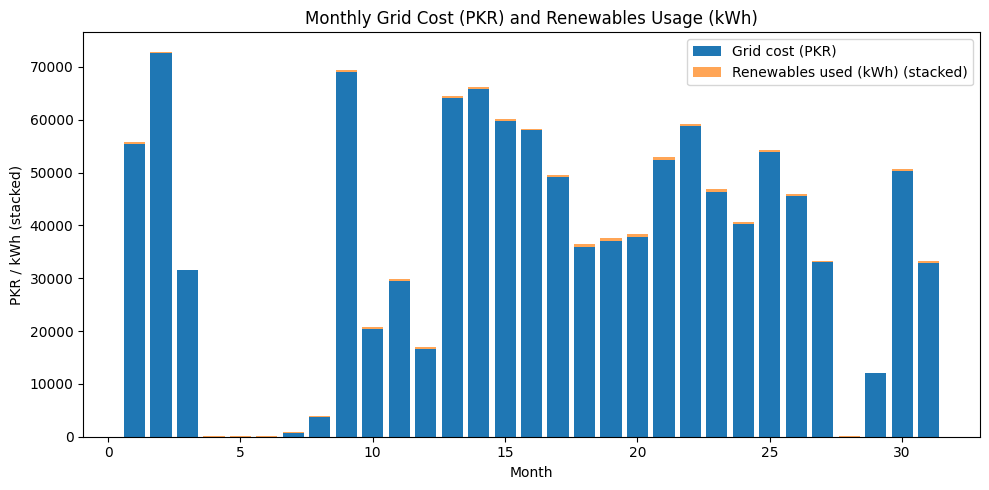

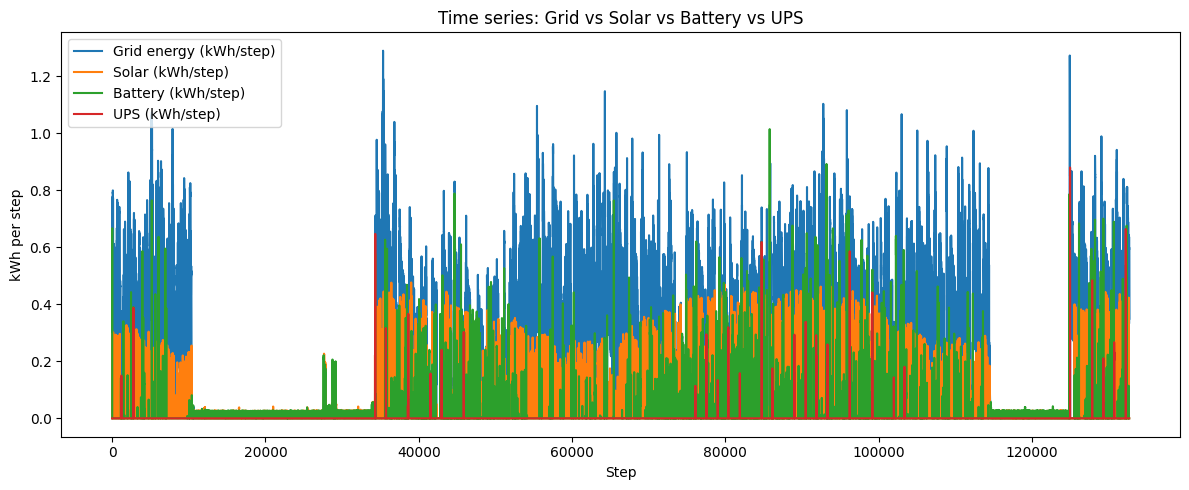

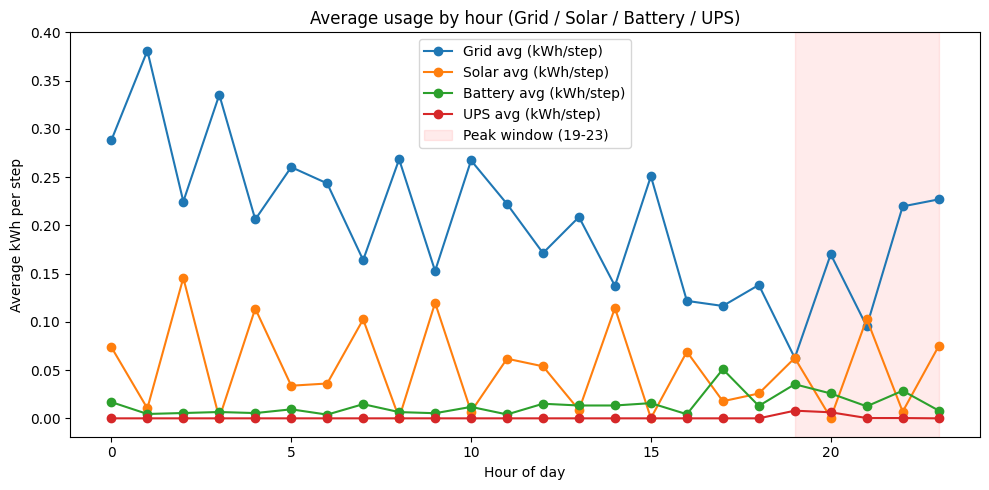

Done.


In [31]:
def make_env():
    return HEMSEnvWithUPS(load_path=LOAD_CSV, pv_profile_df=pv_df_full, renewable_bonus=RENEWABLE_BONUS_STAGE2)

if __name__ == "__main__":
    sample_env = make_env()
    try:
        check_env(sample_env, warn=True)
    except Exception as e:
        print("Env check warning/error:", e)

    vec_env = DummyVecEnv([make_env for _ in range(N_ENVS)])
    vec_env = VecNormalize(vec_env, norm_obs=True, norm_reward=False, clip_obs=10.0)

    policy_kwargs = dict(net_arch=[dict(pi=[256, 256], vf=[256, 256])])

    model = PPO(
        "MlpPolicy",
        vec_env,
        n_steps=2048,
        batch_size=64,
        gae_lambda=0.95,
        gamma=0.99,
        learning_rate=3e-4,
        clip_range=0.2,
        ent_coef=0.0,
        vf_coef=0.5,
        policy_kwargs=policy_kwargs,
        verbose=1,
    )

    # Stage 1
    print(f"Stage 1: {STAGE1_TIMESTEPS} timesteps with renewable bonus {RENEWABLE_BONUS_STAGE1}")
    for e in vec_env.envs:
        try:
            e.renewable_bonus = RENEWABLE_BONUS_STAGE1
        except Exception:
            pass
    model.learn(total_timesteps=STAGE1_TIMESTEPS)
    model.save(MODEL_PATH_STAGE1)
    vec_env.save(VECNORM_PATH)
    print("Saved stage1 model & vecnorm.")

    # Stage 2
    print(f"Stage 2: {STAGE2_TIMESTEPS} timesteps with renewable bonus {RENEWABLE_BONUS_STAGE2}")
    for e in vec_env.envs:
        try:
            e.renewable_bonus = RENEWABLE_BONUS_STAGE2
        except Exception:
            pass
    model.learn(total_timesteps=STAGE2_TIMESTEPS)
    model.save(MODEL_PATH_FINAL)
    vec_env.save(VECNORM_PATH)
    print("Saved final model & vecnorm.")

    # Evaluation
    eval_env = DummyVecEnv([make_env])
    try:
        eval_env = VecNormalize.load(VECNORM_PATH, eval_env)
        eval_env.training = False
        eval_env.norm_reward = False
        print("Loaded VecNormalize for evaluation.")
    except Exception as e:
        print("VecNormalize load error:", e)

    reset_out = eval_env.reset()
    obs = reset_out[0] if isinstance(reset_out, tuple) else reset_out

    total_grid_cost = total_grid_energy = total_solar = total_batt = total_ups = total_fallback = 0.0
    infos = []
    step_count = 0

    while True:
        action, _ = model.predict(obs, deterministic=True)
        next_out = eval_env.step(action)
        if len(next_out) == 5:
            obs, reward, terminated, truncated, info = next_out
        else:
            obs, reward, done_flag, info = next_out
            terminated = bool(done_flag)
            truncated = False

        if isinstance(info, (list, tuple)):
            info = info[0] if len(info) > 0 else {}

        step_count += 1
        gcost = float(info.get("grid_cost", 0.0))
        genergy = float(info.get("grid_energy", 0.0))
        solar_s = info.get("solar_supplied", 0.0)
        batt_s = info.get("battery_supplied", 0.0)
        ups_s = info.get("ups_supplied", 0.0)
        fb = info.get("fallback_grid", 0.0)

        if not np.isfinite(solar_s):
            solar_s = 0.0
        if not np.isfinite(batt_s):
            batt_s = 0.0
        if not np.isfinite(ups_s):
            ups_s = 0.0

        total_grid_cost += gcost
        total_grid_energy += genergy
        total_solar += solar_s
        total_batt += batt_s
        total_ups += ups_s
        total_fallback += fb
        infos.append(info)

        if terminated or truncated:
            break

    # Summary + plots
    print("\n=== Evaluation Summary ===")
    print(f"Steps: {step_count}")
    print(f"Total grid cost (PKR): {total_grid_cost:.2f}")
    print(f"Total grid energy (kWh): {total_grid_energy:.2f}")
    print(f"Total solar supplied (kWh): {total_solar:.2f}")
    print(f"Total battery supplied (kWh): {total_batt:.2f}")
    print(f"Total UPS supplied (kWh): {total_ups:.2f}")
    print(f"Total fallback supplied (kWh): {total_fallback:.2f}")

    grid_costs = np.array([it.get("grid_cost", 0.0) for it in infos])
    solar_uses = np.array([it.get("solar_supplied", 0.0) for it in infos])
    battery_uses = np.array([it.get("battery_supplied", 0.0) for it in infos])
    ups_uses = np.array([it.get("ups_supplied", 0.0) for it in infos])
    grid_energies = np.array([it.get("grid_energy", 0.0) for it in infos])
    hours = np.array([it.get("hour", 0) for it in infos])

    steps_per_day = int((24 * 60) / STEP_MINUTES)
    steps_per_month = steps_per_day * 30
    months = max(1, math.ceil(len(grid_costs) / steps_per_month))

    monthly_grid = []
    monthly_renew = []
    for m in range(months):
        s = m * steps_per_month
        e = min(len(grid_costs), (m + 1) * steps_per_month)
        monthly_grid.append(grid_costs[s:e].sum())
        monthly_renew.append(solar_uses[s:e].sum() + battery_uses[s:e].sum() + ups_uses[s:e].sum())

    months_idx = list(range(1, len(monthly_grid) + 1))
    plt.figure(figsize=(10,5))
    plt.bar(months_idx, monthly_grid, label="Grid cost (PKR)")
    plt.bar(months_idx, monthly_renew, bottom=monthly_grid, label="Renewables used (kWh) (stacked)", alpha=0.7)
    plt.xlabel("Month")
    plt.ylabel("PKR / kWh (stacked)")
    plt.title("Monthly Grid Cost (PKR) and Renewables Usage (kWh)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    t = np.arange(len(grid_energies))
    plt.figure(figsize=(12,5))
    plt.plot(t, grid_energies, label="Grid energy (kWh/step)")
    plt.plot(t, solar_uses, label="Solar (kWh/step)")
    plt.plot(t, battery_uses, label="Battery (kWh/step)")
    plt.plot(t, ups_uses, label="UPS (kWh/step)")
    plt.xlabel("Step")
    plt.ylabel("kWh per step")
    plt.title("Time series: Grid vs Solar vs Battery vs UPS")
    plt.legend()
    plt.tight_layout()
    plt.show()

    avg_grid_by_hour = [grid_energies[hours == h].mean() if np.any(hours == h) else 0.0 for h in range(24)]
    avg_solar_by_hour = [solar_uses[hours == h].mean() if np.any(hours == h) else 0.0 for h in range(24)]
    avg_batt_by_hour = [battery_uses[hours == h].mean() if np.any(hours == h) else 0.0 for h in range(24)]
    avg_ups_by_hour = [ups_uses[hours == h].mean() if np.any(hours == h) else 0.0 for h in range(24)]

    plt.figure(figsize=(10,5))
    plt.plot(range(24), avg_grid_by_hour, marker='o', label='Grid avg (kWh/step)')
    plt.plot(range(24), avg_solar_by_hour, marker='o', label='Solar avg (kWh/step)')
    plt.plot(range(24), avg_batt_by_hour, marker='o', label='Battery avg (kWh/step)')
    plt.plot(range(24), avg_ups_by_hour, marker='o', label='UPS avg (kWh/step)')
    plt.axvspan(19, 23, color='red', alpha=0.08, label='Peak window (19-23)')
    plt.xlabel("Hour of day")
    plt.ylabel("Average kWh per step")
    plt.title("Average usage by hour (Grid / Solar / Battery / UPS)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Done.")

In [ ]:
import pandas as pd
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

# === Load CSV files ===
load_path = "House31.csv"
solar_path = "solar.csv"

# Load solar CSV & compute PV kW
solar_df = pd.read_csv(solar_path, parse_dates=["time"], dayfirst=False).fillna(0.0)
if "pv_kw_est" not in solar_df.columns:
    PEAK_PV_KW = 1.561  # From your earlier solar capacity analysis
    solar_df["pv_kw_est"] = (solar_df["ghi_pyr"] / 1000.0) * PEAK_PV_KW

# === Load trained PPO model ===
model = PPO.load("ppo_hems_grid_cost_opt")

# === Create evaluation environment ===
eval_env_single = HEMSEnvWithUPS(
    load_path=load_path,
    pv_profile_df=solar_df
)

# === Run evaluation ===
oobs, _ = eval_env_single.reset()
done = False
info_list = []

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env_single.step(action)
    done = terminated or truncated
    info_list.append(info)

# === Create DataFrame of step info ===
df_info = pd.DataFrame(info_list)

# Align with time index
start_time = eval_env_single.load_df["Date_Time"].iloc[0]
time_index = pd.date_range(start=start_time, periods=len(df_info), freq="10min")
df_info["time"] = time_index
df_info["month"] = df_info["time"].dt.to_period("M")

# === Monthly stats ===
monthly_stats = df_info.groupby("month").agg({
    "grid_cost": "sum",
    "grid_energy": "sum",
    "solar_supplied": "sum",
    "battery_supplied": "sum",
    "ups_supplied": "sum"
}).reset_index()

# Baseline (all load from grid, no renewables)
avg_price = monthly_stats["grid_cost"].sum() / monthly_stats["grid_energy"].sum()
monthly_stats["baseline_grid_cost"] = monthly_stats["grid_energy"] * avg_price
monthly_stats["savings_PKR"] = monthly_stats["baseline_grid_cost"] - monthly_stats["grid_cost"]

# === Print results ===
print("\n=== Monthly Cost & Savings ===")
print(monthly_stats[["month", "grid_cost", "solar_supplied", "battery_supplied", "ups_supplied", "savings_PKR"]])

# === 3-Year Summary ===
total_savings = monthly_stats["savings_PKR"].sum()
renewable_pct = (
    (monthly_stats["solar_supplied"].sum() +
     monthly_stats["battery_supplied"].sum() +
     monthly_stats["ups_supplied"].sum())
    / (monthly_stats["grid_energy"].sum() +
       monthly_stats["solar_supplied"].sum() +
       monthly_stats["battery_supplied"].sum() +
       monthly_stats["ups_supplied"].sum())
) * 100

print(f"\n=== 3-Year Summary ===")
print(f"Total Savings (PKR): {total_savings:,.2f}")
print(f"Renewable Contribution: {renewable_pct:.2f}%")

# === Plot savings chart ===
plt.figure(figsize=(10,6))
plt.bar(monthly_stats["month"].astype(str), monthly_stats["savings_PKR"])
plt.ylabel("Savings (PKR)")
plt.xlabel("Month")
plt.title("Monthly Savings vs Baseline")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(times, costs)
plt.title(" Cost Over Time")
plt.xlabel("Time Step")
plt.ylabel("Cost (PKR)")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.countplot(x=[action_labels[a] for a in actions])
plt.title("Action Usage Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(times, rewards)
plt.title("PPO Rewards Over Time")
plt.xlabel("Time Step")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(times, socs)
plt.title("Battery SOC Over Time")
plt.xlabel("Time Step")
plt.ylabel("Battery (kWh)")
plt.tight_layout()
plt.show()


Action Distribution Over Time (Stacked Area Plot or Step Plot)

In [ ]:
plt.figure(figsize=(12, 3))
plt.step(times, actions, where='post')
plt.title("Action Taken Over Time")
plt.xlabel("Time Step")
plt.ylabel("Action")
plt.yticks([0, 1, 2, 3], ['Solar', 'Battery', 'UPS', 'Grid'])
plt.grid(True)
plt.tight_layout()
plt.show()


Cumulative Cost

In [ ]:
cumulative_cost = -np.cumsum(rewards)

plt.figure(figsize=(10, 3))
plt.plot(times, cumulative_cost)
plt.title("Cumulative Cost Over Time")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Cost (Rs)")
plt.grid(True)
plt.tight_layout()
plt.show()


Solar vs Load Comparison

In [ ]:
solar_output = []
load_demand = []

# Re-run episode to record solar and load
env = HEMSEnvRealWeather()
obs, _ = env.reset()
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, done, _, _ = env.step(action)
    solar_output.append(env.solar_output)
    load_demand.append(env.load_demand)

plt.figure(figsize=(12, 3))
plt.plot(times, solar_output, label='Solar Output (kW)')
plt.plot(times, load_demand, label='Load Demand (kW)', alpha=0.7)
plt.title("Solar vs Load Over Time")
plt.xlabel("Time Step")
plt.ylabel("Power (kW)")
plt.legend()
plt.tight_layout()
plt.show()


Histogram of Actions (Usage Frequency)

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(actions, bins=np.arange(5)-0.5, rwidth=0.7)
plt.xticks([0, 1, 2, 3], ['Solar', 'Battery', 'UPS', 'Grid'])
plt.title("Action Frequency")
plt.xlabel("Action")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
